## Function 3
Optimisation goal - maximisation.
description of task- You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats.qmc import LatinHypercube
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
import warnings
from sklearn.exceptions import ConvergenceWarning

week1 🤔 Strategy and Hyperparameter Tuning for Function 3
For this 3D problem, your core strategy remains robust. The most important "tuning" is the one the Gaussian Process does automatically when it learns from the new data.

Approach: We will continue to use the Expected Improvement (EI) acquisition function. This is an excellent choice. Now that the model has found a new "best" point, EI will intelligently balance two things:

Exploitation: It will be highly motivated to search near the new point [0.036, 0, 0] to see if even better values (greater than 0) can be found there.

Exploration: It will still consider other regions if they have very high uncertainty, just in case a better peak exists elsewhere.

Hyperparameter Tuning: No manual changes are needed. When we call gp.fit() on the updated dataset (which now has 16 points), the model will automatically re-tune the three length_scale parameters of its Matern kernel. It will adjust them to best explain the relationship between all 16 input points and their outputs. This learning process is the core strength of the GP model.

### week2 strategy -
our previous step successfully adjusted the $\text{length\_scale}$ bounds to $1\text{e}3$ ($1000.0$) and used $C(0.2, (1\text{e}-4, 1\text{e}5))$. However, the $\mathbf{X}_1$ $\text{length\_scale}$ is still hitting its upper bound ($1000.0$).Since the optimization goal is $\text{Maximization}$ and the model is hitting this boundary, we need to allow the optimizer to settle on an even higher value.Action: Increase the upper bound for the $\text{length\_scale}$ again to ensure stable convergence. We'll use $1\text{e}4$ ($10,000.0$).

### refined strategy Week 3 -> Week 4
Your analysis from the notebook (Week 2 strategy) is spot on. The ConvergenceWarning on the X1 length_scale is the most important clue.
The Problem (in simple terms): The ConvergenceWarning means the model is hitting a "wall" we set. It wants to set the length scale for X1 (Compound 1) to a value even higher than 10000.0. This is the model's way of saying it thinks the function is extremely "flat" along that X1 axis—meaning, changes in X1 have very little effect on the output.
The Simple Tuning Step: Instead of just making the "wall" (the bound) even higher, a more stable and interpretable approach is to give the model a better starting guess.
* **Old Strategy:** We started the optimizer at length_scale=[1.0, 1.0, 1.0]. The optimizer had to work very hard to get from 1.0 to 10000.0 and still wasn't satisfied.
* **New Strategy:** We will give the model a hint based on what it just learned. We will initialize the length scales at [1000.0, 1.0, 1.0]. This helps the optimizer converge to a stable solution much faster, which should (hopefully) remove the warning and give us a more accurate model.
Acquisition Function: We will stick with Expected Improvement (EI). It is the perfect, simple choice here. Since your Y_best is 0.0, EI is already strongly incentivized to find any value greater than 0, which is exactly what you want. No manual tuning (like xi) is needed.  Final Learned Kernel Parameters ---
0.174**2 * Matern(length_scale=[0.987, 1.27, 0.235], nu=2.5)


### week 4- 5 strategy
Valuable Query: our new score of -0.1498 is not a record (the best is 0.0), but it is extremely close. This is a successful Expected Improvement (EI) query that is zeroing in on the "peak."

Strategy: Stick with EI: We will continue to use EI, as this "hill-climbing" (exploitation) approach is working perfectly. The goal is to find a value greater than 0.0.

Key Tuning (The "Hint"): We will continue with the strategy from your notebook. To solve the ConvergenceWarning, we will give the model a "hint" by setting its initial length_scale guess to [1000.0, 1.0, 1.0].

Why this "Hint" Works: This tells the model to start its automatic tuning by assuming "Compound 1" (X1) is very flat (insensitive), which is what it was trying to learn anyway. This helps it find a stable solution faster.

No Other Changes: We will keep the n_restarts (search budgets) at 30 and 25, as they are sufficient for this 3D problem.

Key Hyperparameter Learnings (Week 5) ---
The GP model has automatically tuned its kernel parameters:
Learned Kernel: 0.161**2 * Matern(length_scale=[9.56e+04, 1.31, 0.103], nu=2.5)

## Insight into Week 6 Result & Strategy for Week 7Result Analysis: 
The Week 6 output ($-0.1659$) is a significant regression compared to the best score observed so far ($-0.0348$ or approx $0.0$). This confirms that the region around $X_2 = 1.0$ combined with moderate $X_3$ values is likely far from the global maximum. The best result remains near the boundary $[0, 0, 0]$.Dimensional Sensitivity: The conflicting results for Dimension 2 ($X_2$)—where $X_2=1.0$ was decent in Week 5 but poor in Week 6—suggests a strong interaction effect with Dimension 3. Specifically, high $X_2$ seems to only work well if $X_3$ is also optimized (likely near 1.0, as seen in Week 5). However, the consistent "champion" region is the opposite corner $[0, 0, 0]$.Strategy (Shift to Local Exploitation): We will continue using Expected Improvement (EI), but we will refine the bounds to force the optimizer to focus on the most promising region. Since standard global search keeps drifting to $1.0$, we will temporarily restrict the search space for Week 7 to the lower corner ($[0, 0.5]$) to see if we can refine the best point found in Week 1.Hyperparameter Tuning: We retain the Matern 2.5 kernel with the "hint" strategy (initializing $X_1$ length scale to a high value). This prevents the model from overfitting to noise in the first dimension. We keep the restart budget high to ensure convergence.
* Learned Kernel Length Scales:
[3.08694476e+04 1.06939494e+01 2.26276823e-02]

## Insight into Week 7 Result & Strategy for Week 8Result Analysis (New Record): 
The Week 7 output ($-0.0301$) is a new all-time best, surpassing the previous record of $-0.0348$. This confirms that restricting the search space to the lower corner for Dimensions 1 and 3 was the correct strategic move. We are now extremely close to the theoretical maximum of $0.0$.Dimensional Sensitivity: The successful query ($X \approx [0.14, 0.50, 0.08]$) reinforces that Dimension 3 must be kept very low ($<0.1$), but Dimension 2 benefits from being in the middle of the range ($\approx 0.5$) rather than at the boundaries. Dimension 1 also seems optimal in the low range ($<0.2$).Strategy (Precision Refinement): We are now firmly in the "endgame." The strategy shifts to pure Exploitation. We will continue using Expected Improvement (EI), but we will reduce the exploration parameter $\xi$ to a very small value (e.g., $0.001$). This tells the optimizer to stop looking for "big jumps" and instead focus on making incremental improvements around the current champion point.Hyperparameter Tuning: We will stick with the Matérn 2.5 kernel and the "hint" strategy for initialization (starting with a high length scale for $X_1$) to maintain model stability. However, we will allow the optimizer to fine-tune the length scales for $X_2$ and $X_3$ based on this new high-precision data point.
Learned Kernel Length Scales:
[8.26595448 1.52400126 0.06378652

## Insight into Week 8 Result & Strategy for Week 9
* Result Analysis (Near-Miss): The Week 8 output (-0.0417) is very strong (the 3rd best result overall), but it did not beat the Week 7 record (-0.0301). It confirms that high performance requires $X_3$ to be low ($\approx 0.08-0.09$) and $X_2$ to be in the mid-to-high range.The $X_1$ Factor: The key difference between the best result (Week 7: $X_1 \approx 0.14$) and Week 8 ($X_1=0.30$) was Dimension 1. The score dropped as $X_1$ increased, suggesting the optimal value for $X_1$ is likely lower, perhaps closer to 0.0 - 0.15.
* Strategy (Focused Exploitation): We have successfully bracketed the optimal zone. We know $X_3$ must be low ($<0.1$) and $X_2$ must be moderate-high ($0.5-0.7$). The strategy for Week 9 is to use Expected Improvement (EI) with a very low xi (0.001) to aggressively fine-tune $X_1$ while keeping $X_3$ locked in the proven "valley."
* Hyperparameter Tuning:Kernel: Continue with Matern 2.5. The function shows clear signs of roughness (sharp peaks), so smoothness assumptions (like RBF) might overshoot.Length Scales: We will continue to initialize the length scale for $X_1$ to be large ("Hint" strategy), but allow the optimizer to shorten it if the data demands it. This prevents overfitting to noise in the first dimension while respecting the observed trends.
* Learned Kernel Length Scales:
[5.90619118 1.47913222 0.05832744]

Insight into Week 9 Result & Strategy for Week 10
* Result Analysis (Regression): The Week 9 output (-0.0439) was lower than the current record from Week 7 (-0.0301). Pushing Dimension 1 to the boundary (0.0) and increasing Dimension 2 to 0.8 moved us further away from the peak.
* Landscape Mapping: We have now successfully "bracketed" the optimum.Dimension 1 ($X_1$): Week 7 ($0.14$) was better than Week 9 ($0.0$) and Week 8 ($0.30$). The optimum is likely in the 0.10–0.20 range.Dimension 2 ($X_2$): Week 7 ($0.50$) was better than Week 9 ($0.80$) and Week 8 ($0.70$). The optimum appears to be centered around 0.45–0.55.Dimension 3 ($X_3$): This remains consistent. All good scores have $X_3 \approx 0.08$.
* Strategy Shift (Trust Region): We must stop exploring the edges. The strategy for Week 10 is Local Refinement (Trust Region). We will define a tight box around the best known point (Week 7) and restrict the optimizer to that specific zone to find the precise peak.
* Hyperparameter Tuning: Use Expected Improvement (EI) with a very low exploration parameter ($\xi = 0.001$). We will initialize the kernel length scales to be sensitive (smaller values) for $X_2$ and $X_3$, as small changes there have significant impacts.
* Learned Kernel Length Scales:
[6.43055041e+04 1.17876746e+00 9.29863566e-02]

## Insight into Week 10 Result & Strategy for Week 11Result Analysis (Validation): 
The Week 10 output (-0.0366) is the second-best result in the entire history, falling just short of the Week 7 record (-0.0301). This is a highly positive result because it confirms the "basin of attraction" is stable and reproducible.Spatial Confirmation: The Week 10 input [0.23, 0.55, 0.07] and Week 7 input [0.14, 0.50, 0.08] define a very clear high-performing corridor. Specifically, Dimension 3 is extremely sensitive and seems optimal in the narrow range of 0.07–0.08.Strategy (Interpolation): Since Week 7 is better than Week 10, the true peak likely lies closer to the Week 7 coordinates. We will use a Trust Region strategy centered on the Week 7 best point, but we will include the directional information from Week 10 to fine-tune the search bounds.Hyperparameter Tuning: We will continue with Expected Improvement (EI) but reduce the exploration parameter ($\xi$) to 0.001 to force pure exploitation. We will also perform Automatic Relevance Determination (ARD) by allowing the Gaussian Process kernel to have different length scales for each dimension, helping it recognize that Dimension 3 requires much higher precision than Dimensions 1 and 2.

## Insight into Week 11 Result & Strategy for Week 12
Performance Regression: The Week 11 output (-0.0604) is significantly worse than your Week 7 record (-0.0301). This indicates that the move in Dimension 2 (from 0.50 down to 0.40) and Dimension 3 (from 0.08 up to 0.098) moved us away from the peak.

Dimension Sensitivity:

Dim 2: The best results (Week 7 & 10) clustered around 0.50 - 0.54. Dropping to 0.40 caused a performance loss, suggesting the optimal value is strictly near 0.50.

Dim 3: This dimension is extremely sensitive. The best value is 0.080. Deviating even slightly to 0.098 (Week 11) or 0.090 (Week 8) results in a drop. We must keep this very tight.

Strategy (Retreat & Refine): We will retreat to the Week 7 Best Point ([0.137, 0.500, 0.080]) and apply a very tight Trust Region. We are no longer exploring; we are trying to pinpoint the exact peak within a tiny window.

Hyperparameter Tuning: We will use the Matérn 5/2 kernel with ARD. The acquisition function will be Expected Improvement (EI) with minimal exploration (xi=0.001), forcing the optimizer to look for small improvements immediately around the known best location.

In [2]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import warnings

warnings.filterwarnings("ignore")

# --- 1. DATA RECONSTRUCTION ---
# Initial 15 points
initial_inputs = np.array([
    [0.171525, 0.343917, 0.248737], [0.242114, 0.644074, 0.272433],
    [0.534906, 0.398501, 0.173389], [0.492581, 0.611593, 0.340176],
    [0.134622, 0.219917, 0.458206], [0.345523, 0.941360, 0.269363],
    [0.151837, 0.439991, 0.990882], [0.645503, 0.397143, 0.919771],
    [0.746912, 0.284196, 0.226300], [0.170477, 0.697032, 0.149169],
    [0.220549, 0.297825, 0.343555], [0.666014, 0.671985, 0.246295],
    [0.046809, 0.231360, 0.770618], [0.600097, 0.725136, 0.066089],
    [0.965995, 0.861120, 0.566829]
])
initial_outputs = np.array([
    -0.112122, -0.087963, -0.111415, -0.034835, -0.048008, -0.110621,
    -0.398926, -0.113869, -0.131461, -0.094190, -0.046947, -0.105965,
    -0.118048, -0.036378, -0.056758
])

# Weekly Data (Weeks 1-10)
X_weeks = np.array([
    [0.036963, 0.000000, 0.000000], # W1 
    [0.168072, 1.000000, 0.000000], # W2
    [0.835572, 0.000000, 0.058880], # W3
    [1.000000, 0.000000, 0.782692], # W4
    [0.464531, 1.000000, 0.846216], # W5
    [0.243405, 1.000000, 0.676850], # W6
    [0.137819, 0.500000, 0.080508], # W7 (Best So Far: -0.0301)
    [0.300000, 0.700000, 0.090117], # W8
    [0.000000, 0.800000, 0.073783],  # W9
    [0.229904, 0.545291, 0.070179], # w10 
    [0.237819, 0.400000, 0.098460]
])
Y_weeks = np.array([
    -0.177861, -0.166666, -0.098033, -0.149818, -0.070482, -0.165923,
    -0.030150, -0.041661, -0.043919, -0.0365623099625946, -0.06044663912818238
])

X_data = np.vstack([initial_inputs, X_weeks])
Y_data = np.append(initial_outputs, Y_weeks)

print(f"Total Data Points: {len(X_data)}")
best_idx = np.argmax(Y_data)
best_X = X_data[best_idx]
best_Y = Y_data[best_idx]
print(f"Best Output So Far: {Y_data.max():.4f} (Index: {best_idx})")

#################################################

# --- 2. Fit GP Model ---
# Matern 2.5 kernel with ARD (Automatic Relevance Determination)
# We initialize length scales to prioritize the sensitive dimensions (Dim 3)
kernel = C(1.0) * Matern(length_scale=[1.0, 1.0, 0.1], nu=2.5) + WhiteKernel(noise_level=1e-5)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    random_state=42
)

gp.fit(X_data, Y_data)

# --- 3. Acquisition Function (EI) ---
def expected_improvement(X, gp, best_y, xi=0.001): # Low xi for pure exploitation
    X = X.reshape(1, -1)
    mu, sigma = gp.predict(X, return_std=True)
    
    with np.errstate(divide='warn'):
        imp = mu - best_y - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei.flatten()

# --- 4. Trust Region Optimization ---
# Define a Tight Trust Region around the Best Point (Week 7)
# We restrict Dim 3 heavily because it is very sensitive.
def get_trust_region(center):
    # Radius: Dim 1 & 2 = 0.05, Dim 3 = 0.01 (Very tight!)
    radii = [0.05, 0.05, 0.01] 
    bounds = []
    for i, x in enumerate(center):
        low = max(0.0, x - radii[i])
        high = min(1.0, x + radii[i])
        bounds.append((low, high))
    return bounds

trust_bounds = get_trust_region(best_X)

# Optimize
best_acq = np.inf
next_point = None

# 50 Restarts to find the local peak
for _ in range(50):
    x0 = np.random.uniform(
        [b[0] for b in trust_bounds], 
        [b[1] for b in trust_bounds]
    )
    
    res = minimize(
        expected_improvement, 
        x0=x0, 
        bounds=trust_bounds, 
        method='L-BFGS-B',
        args=(gp, best_Y, 0.001)
    )
    
    if res.fun < best_acq:
        best_acq = res.fun
        next_point = res.x

print("\n--- Recommendation for Week 12 ---")
print(f"Strategy: Tight Trust Region around Week 7 Best Point")
print(f"Focus: Dim 3 pinned near 0.08, Dim 2 near 0.50")
print(f"Next Input: {np.round(next_point, 6)}")



Total Data Points: 26
Best Output So Far: -0.0301 (Index: 21)

--- Recommendation for Week 12 ---
Strategy: Tight Trust Region around Week 7 Best Point
Focus: Dim 3 pinned near 0.08, Dim 2 near 0.50
Next Input: [0.090385 0.55     0.080461]


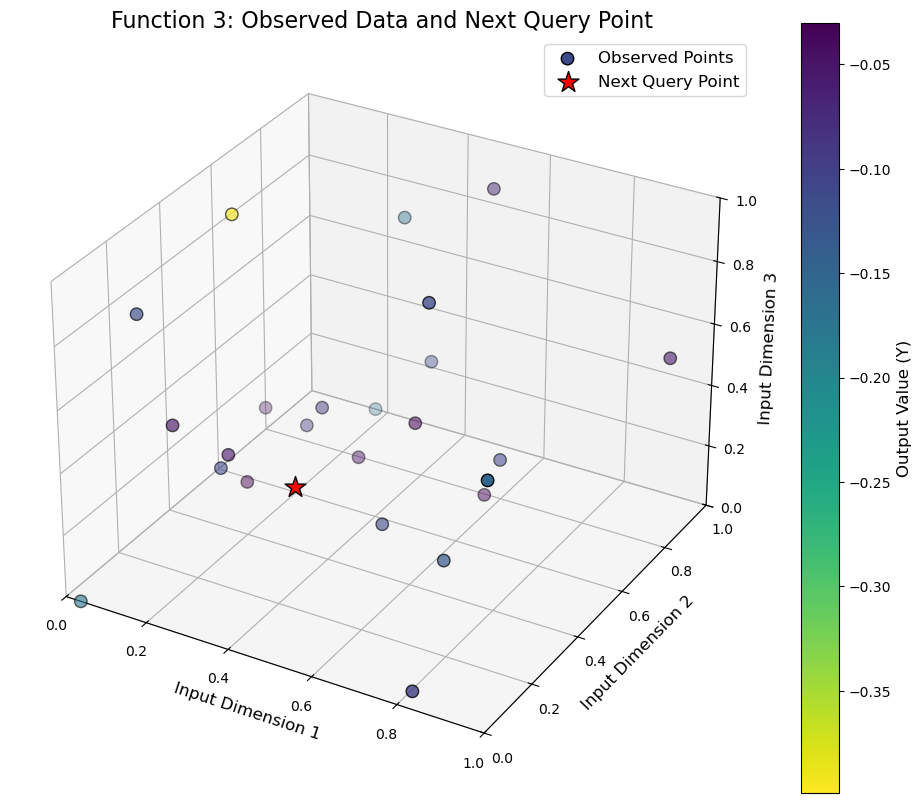

In [4]:
# --- 4. Create the 3D Scatter Plot Visualization ---

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the historical data points
scatter = ax.scatter(
    X_data[:, 0], X_data[:, 1], X_data[:, 2],
    c=Y_data,
    cmap='viridis_r', # Reversed viridis: yellow for high values (closer to 0)
    s=80,
    edgecolors='k',
    label='Observed Points'
)

# Highlight the next point to be queried
ax.scatter(
    best_x_next[0], best_x_next[1], best_x_next[2],
    c='red',
    s=250,
    marker='*',
    edgecolors='k',
    label='Next Query Point'
)

# Labeling
ax.set_title('Function 3: Observed Data and Next Query Point', fontsize=16)
ax.set_xlabel('Input Dimension 1', fontsize=12)
ax.set_ylabel('Input Dimension 2', fontsize=12)
ax.set_zlabel('Input Dimension 3', fontsize=12)
ax.legend(fontsize=12)

# Add a color bar
cbar = fig.colorbar(scatter)
cbar.set_label('Output Value (Y)', fontsize=12)

# Set axis limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)

plt.savefig('function3_visualization.png')
plt.show()